In [1]:
from load import LABELS, load_feature
from cnn import run_pipeline

In [2]:
train_x, train_y, label_encoder = load_feature("train","mfcc_cache")
val_x, val_y = load_feature("val", "mfcc_cache", label_encoder)
test_x, test_y = load_feature("test", "mfcc_cache", label_encoder)

Using device: cuda
train_x shape: torch.Size([30239, 1, 13, 126])
Number of classes: 48
CNNModel(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): AdaptiveAvgPool2d(output_size=(4, 4))
  )
  (classifier

c:\Users\bayub\Documents\chord-classification\cnn.py:219: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(save_path))



Test Accuracy : 0.8605
Test Loss     : 1.2800
Precision     : 0.8948
Recall        : 0.8605
F1 Score      : 0.8549

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.58      0.68       180
           1       1.00      0.96      0.98       180
           2       0.91      0.92      0.91       180
           3       0.83      0.92      0.87       180
           4       0.63      0.85      0.73       180
           5       0.96      1.00      0.98       180
           6       0.94      0.97      0.95       180
           7       0.98      0.99      0.98       180
           8       0.85      0.89      0.87       180
           9       1.00      0.99      0.99       180
          10       0.93      0.29      0.45       180
          11       1.00      0.88      0.93       180
          12       0.91      0.96      0.94       180
          13       1.00      1.00      1.00       180
          14       0.56      0.99      0.72      

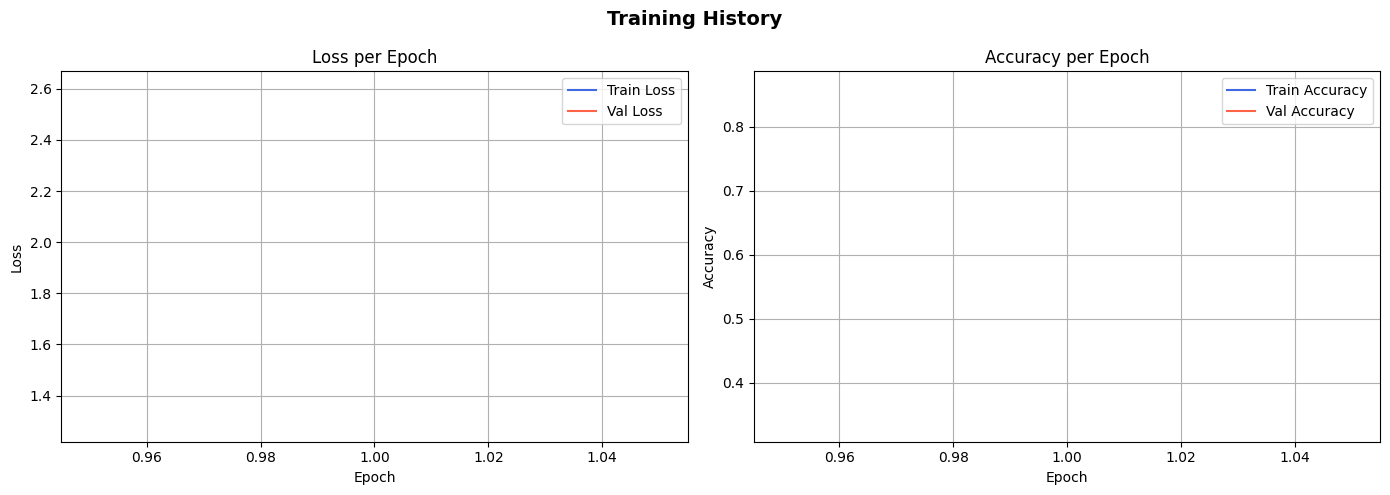

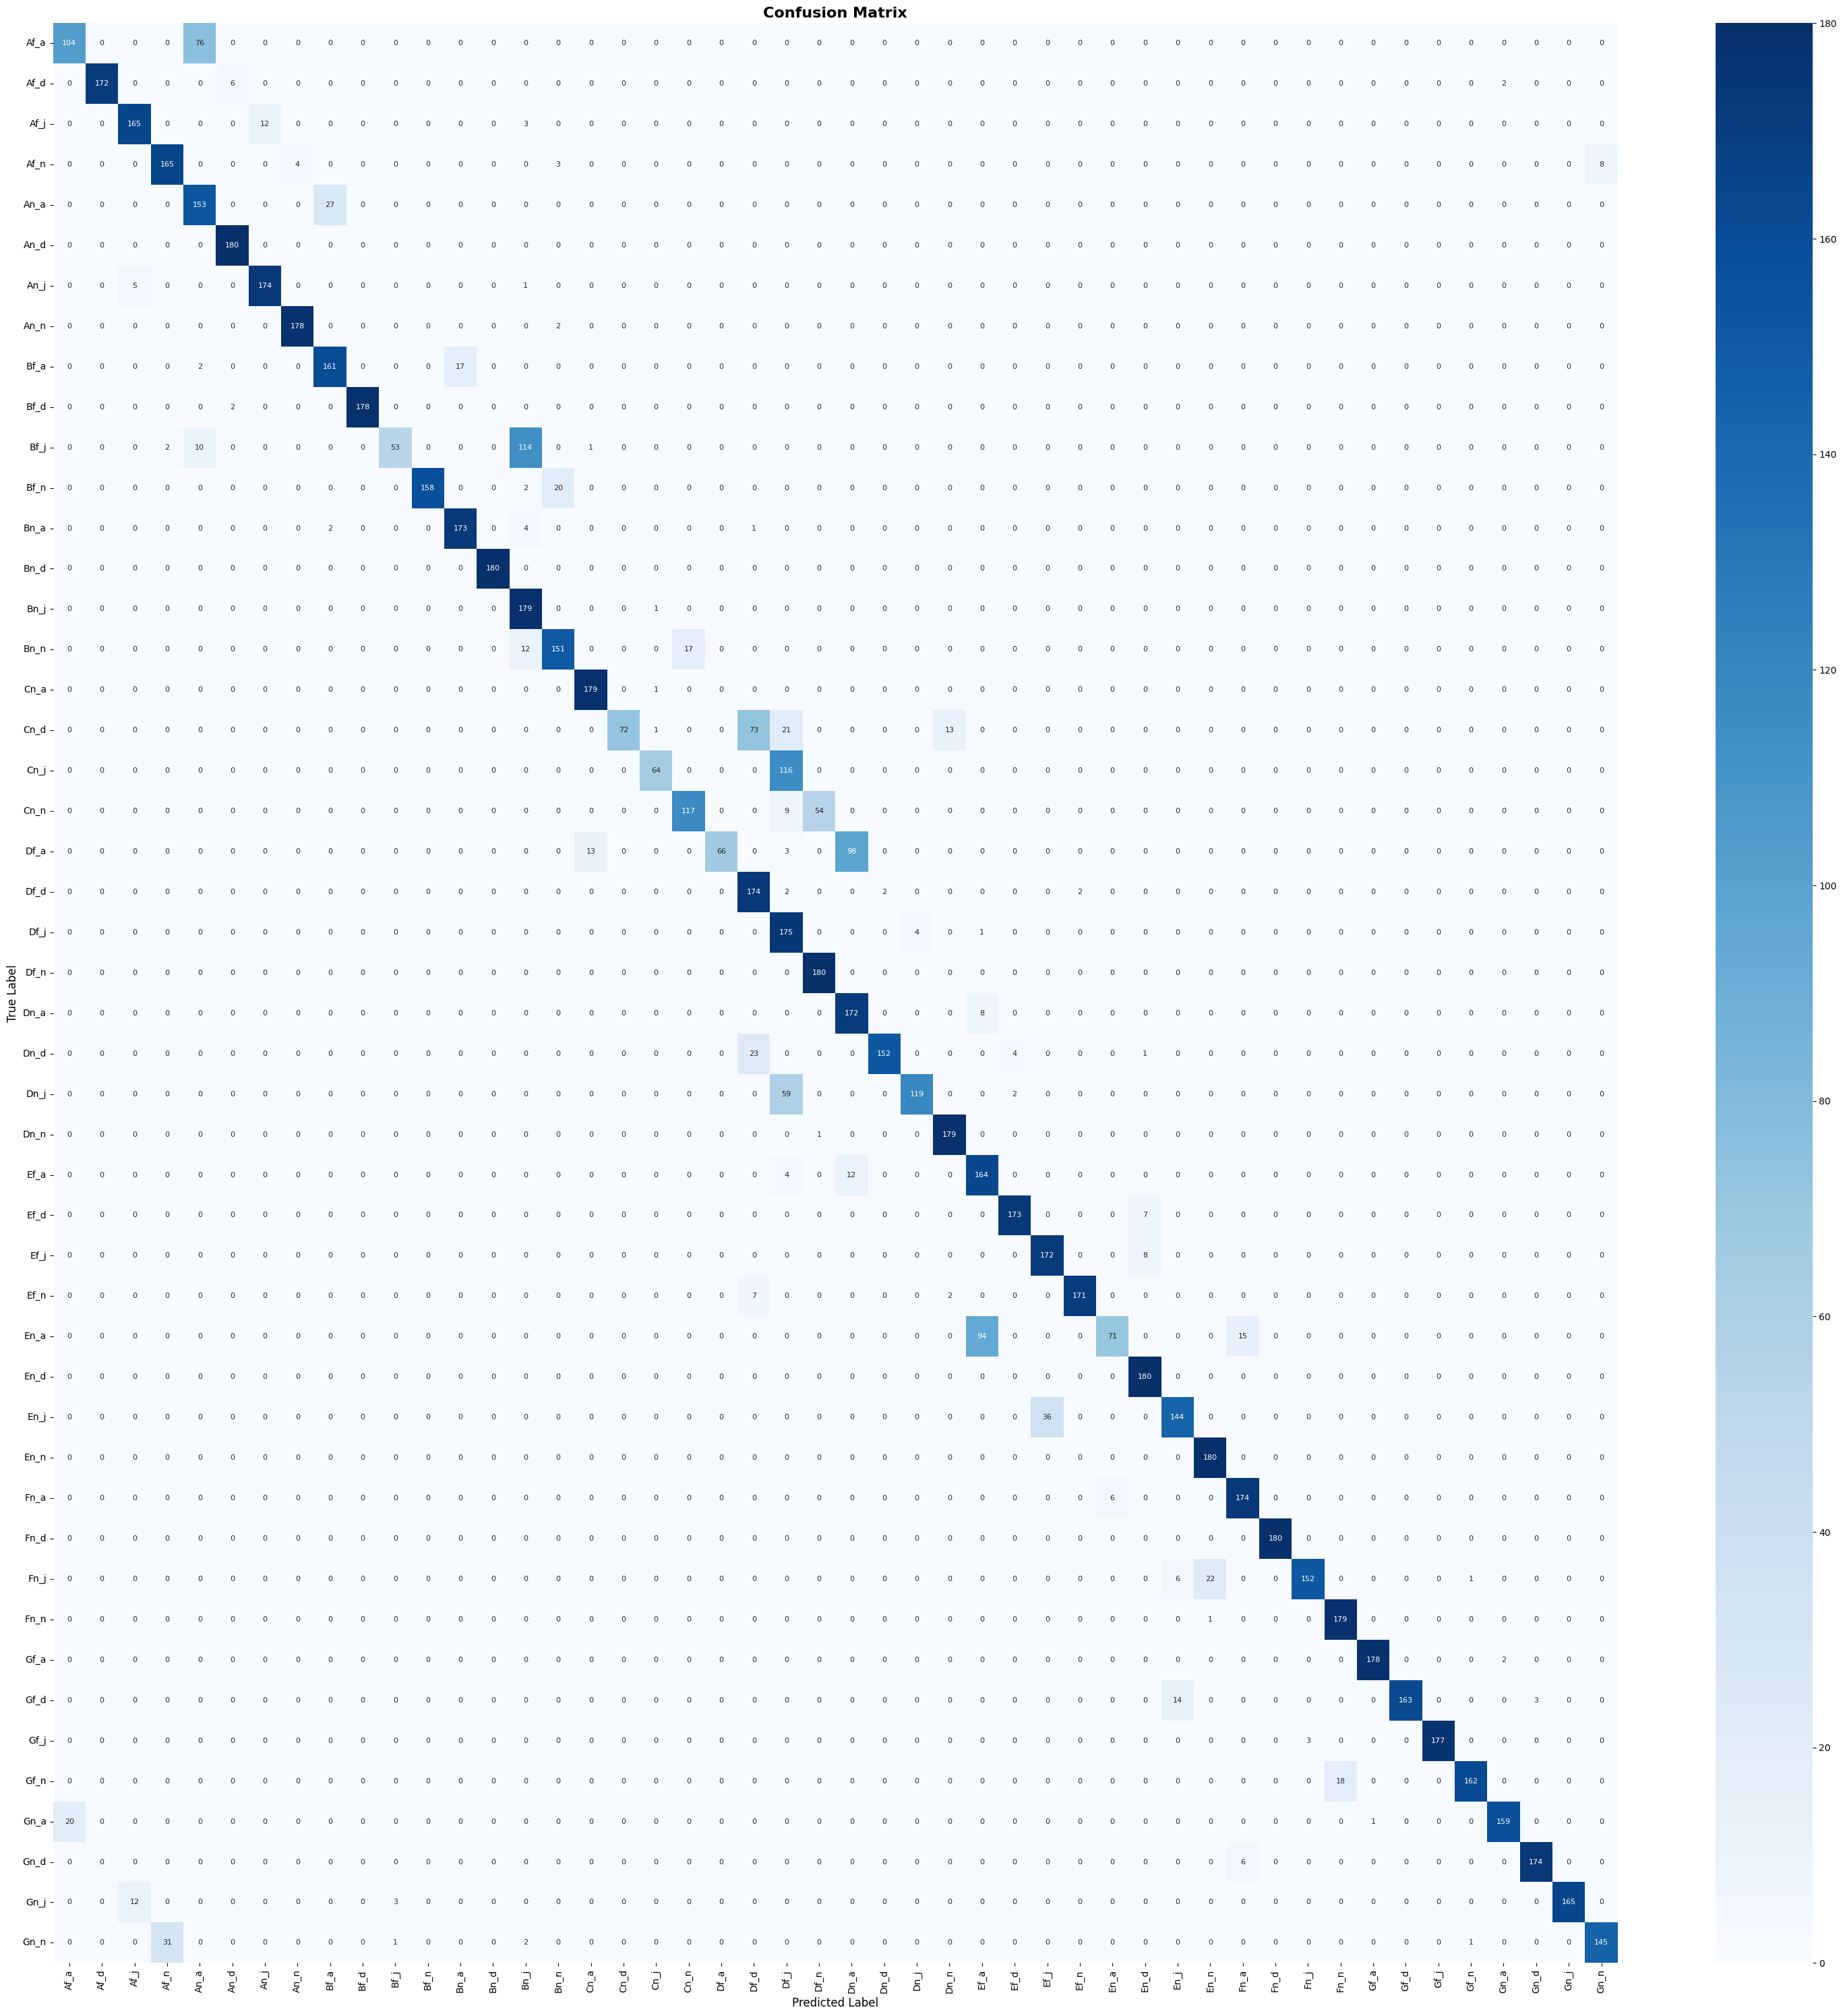

In [ ]:
run_pipeline(
    train_x, train_y,
    val_x,   val_y,
    test_x,  test_y,
    labels=LABELS,
    epochs=30,
    patience=10,
    batch_size=32,
    scenario = "mfcc"
)